Requested m/z: 760.585
Closest m/z : 760.5856


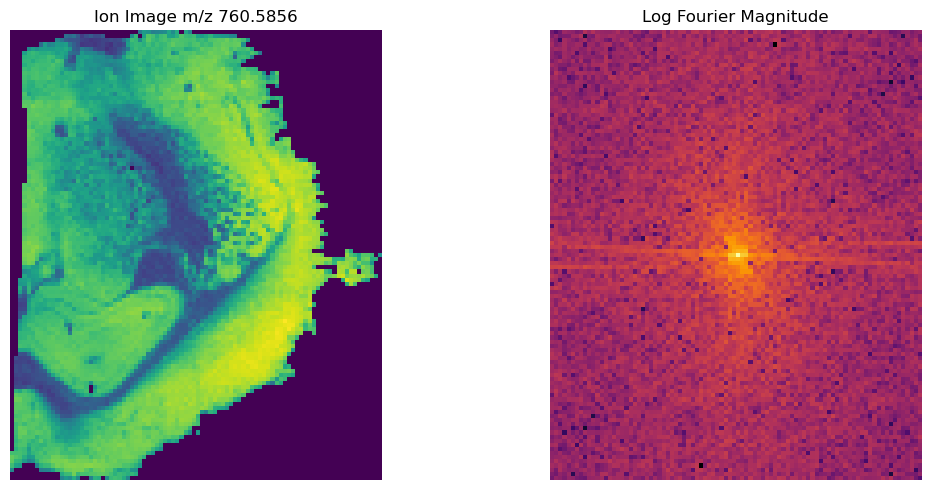

In [73]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import issparse

# --------------------------------------------------
# Load h5ad
# --------------------------------------------------
file_path = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered_halfbrain_common_synced/halfbrain_yc_1_filtered_common_synced.h5ad"

adata = sc.read_h5ad(file_path)

# --------------------------------------------------
# Select m/z
# --------------------------------------------------
target_mz = 760.585  # change this

mz_values = adata.var_names.astype(float)

idx = np.argmin(np.abs(mz_values - target_mz))

print(f"Requested m/z: {target_mz}")
print(f"Closest m/z : {mz_values[idx]}")

# --------------------------------------------------
# Extract intensities
# --------------------------------------------------
if issparse(adata.X):
    intensities = adata.X[:, idx].toarray().flatten()
else:
    intensities = np.asarray(adata.X[:, idx]).flatten()

# --------------------------------------------------
# Build 2D ion image
# --------------------------------------------------
x = adata.obs["x"].astype(int).values
y = adata.obs["y"].astype(int).values

width = x.max() + 1
height = y.max() + 1

image = np.zeros((height, width))
image[y, x] = intensities

# --------------------------------------------------
# Compute 2D Fourier Transform
# --------------------------------------------------
F = np.fft.fft2(image)
F_shift = np.fft.fftshift(F)

magnitude = np.abs(F_shift)
log_magnitude = np.log1p(magnitude)

# --------------------------------------------------
# Plot ion image and Fourier spectrum
# --------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(image, cmap="viridis")
ax[0].set_title(f"Ion Image m/z {mz_values[idx]:.4f}")
ax[0].axis("off")

ax[1].imshow(log_magnitude, cmap="inferno")
ax[1].set_title("Log Fourier Magnitude")
ax[1].axis("off")

plt.tight_layout()
plt.show()


In [74]:

F = np.fft.fft2(image)

k = 5000  # keep top 50 frequencies

idx = np.argsort(np.abs(F).ravel())[-k:]

rows, cols = np.unravel_index(idx, F.shape)

for u, v in zip(rows, cols):
    amp = np.abs(F[u,v])
    phase = np.angle(F[u,v])

    print(u, v, amp, phase)

67 26 7185084.480124167 -1.9731793837630667
42 64 7185084.480124168 1.9731793837630665
105 45 7187125.283361424 0.60236075842048
4 45 7187125.283361426 -0.6023607584204806
42 78 7187272.266623739 -0.5161838618292027
67 12 7187272.266623743 0.5161838618292023
64 41 7191173.691883415 -0.4743252790983188
45 49 7191173.691883423 0.4743252790983196
6 70 7193703.221645869 2.5106728101406453
103 20 7193703.2216458805 -2.5106728101406426
75 52 7194210.3273605695 -1.9247082006721021
34 38 7194210.327360583 1.9247082006721001
15 85 7197515.839395253 2.989930384145532
94 5 7197515.8393952595 -2.9899303841455325
73 74 7202061.062999569 1.9532458450053283
36 16 7202061.062999573 -1.953245845005329
50 11 7204076.382895688 1.2421863281217784
59 79 7204076.3828957025 -1.242186328121778
58 75 7206199.345488766 2.0834785850006066
51 15 7206199.345488767 -2.0834785850006075
11 43 7207655.562134648 -1.7980284133209503
98 47 7207655.562134651 1.7980284133209512
59 69 7208142.57805643 1.1705946493728117
50 

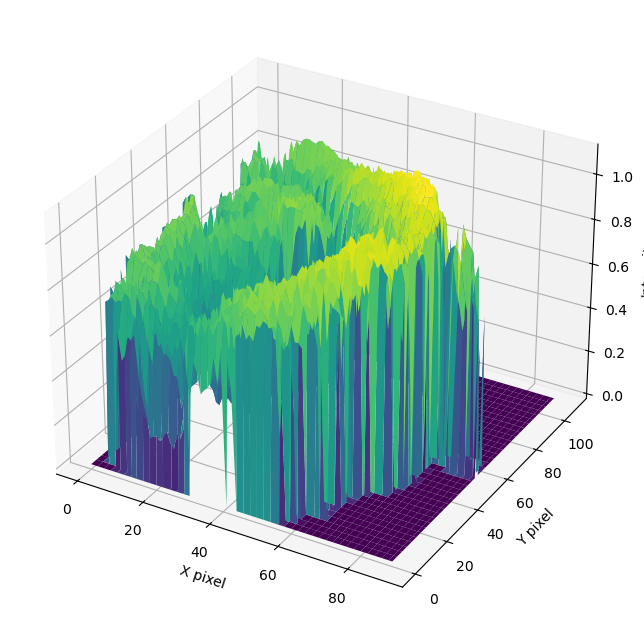

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# image = your reconstructed ion image

y, x = np.indices(image.shape)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    x,
    y,
    image,
    cmap='viridis',
    linewidth=0
)

ax.set_xlabel('X pixel')
ax.set_ylabel('Y pixel')
ax.set_zlabel('Intensity')

plt.show()

In [76]:
F = np.fft.fft2(image)

K = 5000

flat_idx = np.argsort(np.abs(F).ravel())[-K:]
u_idx, v_idx = np.unravel_index(flat_idx, F.shape)

terms = []

for u, v in zip(u_idx, v_idx):
    amp = np.abs(F[u, v]) / image.size
    phase = np.angle(F[u, v])

    terms.append((u, v, amp, phase))


In [77]:
M, N = image.shape

y, x = np.meshgrid(
    np.arange(M),
    np.arange(N),
    indexing='ij'
)

surface = np.zeros((M, N))

for u, v, amp, phase in terms:
    surface += amp * np.cos(
        2*np.pi*(u*x/N + v*y/M) + phase
    )

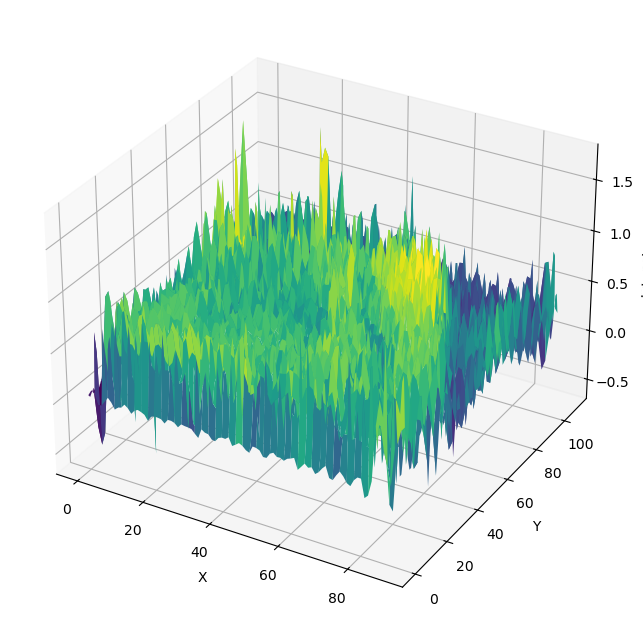

In [78]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    x,
    y,
    surface,
    cmap='viridis',
    linewidth=0
)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Intensity')

plt.show()

In [79]:
import plotly.graph_objects as go
import numpy as np

# image = 2D ion image (height x width)

y = np.arange(image.shape[0])
x = np.arange(image.shape[1])

fig = go.Figure(
    data=[
        go.Surface(
            z=image,
            x=x,
            y=y,
            colorscale="Viridis"
        )
    ]
)

fig.update_layout(
    title="MSI Ion Image Surface Plot",
    scene=dict(
        xaxis_title="X Pixel",
        yaxis_title="Y Pixel",
        zaxis_title="Intensity"
    ),
    width=1000,
    height=800
)

fig.show()

In [80]:
F = np.fft.fft2(image)

In [81]:
K = 500

mask = np.zeros_like(F, dtype=bool)

idx = np.argsort(np.abs(F).ravel())[-K:]
mask.ravel()[idx] = True

F_sparse = np.where(mask, F, 0)

reconstructed = np.real(np.fft.ifft2(F_sparse))

In [82]:
z=image

In [83]:
z=reconstructed

In [84]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "surface"},
            {"type": "surface"}]],
    subplot_titles=("Original", "Fourier Reconstruction")
)

fig.add_trace(
    go.Surface(z=image, showscale=False),
    row=1, col=1
)

fig.add_trace(
    go.Surface(z=reconstructed, showscale=False),
    row=1, col=2
)

fig.update_layout(
    width=1400,
    height=700
)

fig.show()

In [85]:
adata.obs["x"]
adata.obs["y"]

303        0
304        0
305        0
306        0
307        0
        ... 
18030    108
18031    108
18032    108
18033    108
18034    108
Name: y, Length: 6688, dtype: int64

In [86]:
x = adata.obs["x"].astype(int).values
y = adata.obs["y"].astype(int).values

image = np.zeros((y.max()+1, x.max()+1))
image[y, x] = intensities

In [90]:
F = np.fft.fft2(image)
M, N = F.shape

In [91]:
def hex_grid(nx, ny):
    xs, ys = [], []

    for j in range(ny):
        for i in range(nx):
            xs.append(i + 0.5 * j)
            ys.append((np.sqrt(3)/2) * j)

    return np.array(xs), np.array(ys)

In [92]:
def fourier_eval(F, x, y):
    M, N = F.shape

    u = np.arange(M)[:, None]
    v = np.arange(N)[None, :]

    phase = np.exp(2j * np.pi * (u * x / M + v * y / N))

    return np.real(np.sum(F * phase))

In [93]:
Xh, Yh = hex_grid(image.shape[1], image.shape[0])

Z = np.zeros(len(Xh))

for i in range(len(Xh)):
    Z[i] = fourier_eval(F, Xh[i], Yh[i])

In [94]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=Xh,
        y=Yh,
        z=Z,
        intensity=Z,
        colorscale="Viridis",
        opacity=1
    )
)

fig.show()

In [1]:
"""
MSI → RNA Grid Transfer (Single File, Multiprocessing)
=======================================================
Reads ONE MSI .h5ad file, mathematically characterizes each m/z spatial
pattern, and reconstructs it on RNA hexagonal grid coordinates.

Features are transferred in parallel using multiprocessing for speed.

Three reconstruction methods:
  1. RBF (default):  Radial Basis Function interpolation. General-purpose,
                     handles arbitrary patterns well.
  2. FFT (Fourier):  2D FFT on Cartesian MSI → Non-Uniform DFT evaluation
                     at RNA hex coords. Best for periodic/wave patterns.
  3. Spline:         Cubic spline via scipy.interpolate.griddata.
                     Fast, good for smooth patterns.

Integrates with:
  - Ground_truth_data_producer_50_cmplx_pttrn_fixed.py  (data format)
  - 0_0_1_test_data_plotter_saver.py  (visualization conventions)

Data conventions (matching your pipeline):
  - MSI features:  "MZ_<PatternName>"   → output RNA: "Gene_<PatternName>"
  - Coordinates:   obs['x_um'], obs['y_um'] in micrometers
  - MSI grid:      60µm Cartesian
  - RNA grid:      100µm hex spacing, 55µm spot diameter
  - Field:         6000 × 6000 µm

Usage:
  python msi_pattern_to_rna_grid.py
"""

import numpy as np
import pandas as pd
import anndata as ad
from scipy import interpolate, ndimage
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import LinearSegmentedColormap
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
import warnings
import os
import time

warnings.filterwarnings('ignore')


# =============================================================================
# CONFIGURATION — Edit these for your environment
# =============================================================================

# Input: path to a single MSI .h5ad file
MSI_FILE = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered_halfbrain_common_synced/halfbrain_yc_1_filtered_common_synced.h5ad"

# Output directory
OUTPUT_DIR = "/home/ajarrah/PhD_Thesis/fourier transform/output/"

# Grid specs (must match your Ground_truth_data_producer)
FIELD_WIDTH  = 6000   # µm
FIELD_HEIGHT = 6000   # µm
MSI_PIXEL_SIZE   = 60    # µm  (Cartesian grid spacing)
RNA_SPOT_SPACING = 100   # µm  (hex grid center-to-center)
RNA_SPOT_DIAMETER = 55   # µm  (Visium spot diameter)

# Transfer method: 'rbf', 'fft', or 'spline'
METHOD = "rbf"

# Tissue mask: max distance (µm) from any MSI pixel for an RNA spot
# to be considered "in tissue". ~1.5× the MSI pixel size works well.
TISSUE_MAX_DIST = 90  # µm

# Feature renaming: MZ_X → Gene_X
RENAME_FEATURES = True

# Multiprocessing
N_WORKERS = max(1, mp.cpu_count() - 1)   # leave 1 core free; set to 1 for serial

# RBF options
RBF_KERNEL = "thin_plate_spline"  # 'thin_plate_spline', 'multiquadric', 'cubic', 'gaussian'
RBF_SMOOTHING = 0.0               # 0 = exact interpolation
RBF_MAX_POINTS = 8000             # Subsample MSI if larger (RBF is O(n²) memory)

# FFT options
FFT_ZERO_PAD_FACTOR = 2           # 1 = no padding, 2 = double resolution
FFT_LOW_PASS_SIGMA = None         # Gaussian low-pass σ in freq domain (None = off)

# Spline options
SPLINE_METHOD = "cubic"           # 'linear', 'cubic', 'nearest'

# Plotting
PLOT_DIAGNOSTICS = True
PLOT_MAX_FEATURES = 528            # Max features to plot (set 0 to skip)
PLOT_DPI = 150
IMAGE_SHOW = False  # Set to True to display plots interactively (may slow down batch runs)

# Custom colourmap (dark → navy → blue → purple → red → orange → yellow → white)
CUSTOM_CMAP = LinearSegmentedColormap.from_list("msi_heatmap", [
    (0.00,       "#454545"),
    (0.00000001, "#000000"),
    (0.10,       "#000080"),
    (0.15,       "#0000FF"),
    (0.30,       "#8000FF"),
    (0.45,       "#FF0000"),
    (0.60,       "#FF8000"),
    (0.75,       "#FFFF00"),
    (1.00,       "#FFFFFF"),
])

# =============================================================================
# GRID GENERATION (identical to your Ground_truth_data_producer)
# =============================================================================

def get_visium_hex_grid(width, height, spacing=100):
    """Generate Visium-like hexagonal grid coordinates."""
    dy = spacing * np.sqrt(3) / 2
    coords = []
    row = 0
    y = 0.0
    while y < height:
        x_offset = (spacing / 2) if row % 2 == 1 else 0
        x = x_offset
        while x < width:
            coords.append([x, y])
            x += spacing
        y += dy
        row += 1
    return np.array(coords)


def get_cartesian_grid(width, height, spacing):
    """Generate Cartesian grid coordinates."""
    x = np.arange(0, width, spacing)
    y = np.arange(0, height, spacing)
    xx, yy = np.meshgrid(x, y)
    return np.column_stack((xx.ravel(), yy.ravel()))


# =============================================================================
# TISSUE MASK TRANSFER
# =============================================================================

def transfer_tissue_mask(msi_coords, target_coords, max_dist):
    """
    Determine which RNA spots fall within the MSI tissue footprint.
    An RNA spot is 'in tissue' if its nearest MSI pixel is within max_dist.
    """
    tree = cKDTree(msi_coords)
    distances, _ = tree.query(target_coords, k=1)
    return distances <= max_dist


# =============================================================================
# METHOD 1: RBF INTERPOLATION (recommended default)
# =============================================================================

def transfer_rbf(msi_coords, values, target_coords,
                 kernel=RBF_KERNEL, smoothing=RBF_SMOOTHING,
                 max_points=RBF_MAX_POINTS):
    """
    Fit Radial Basis Function to MSI data, evaluate at target (RNA) coords.

    Model:  f(x,y) = Σᵢ wᵢ · φ(‖(x,y) - (xᵢ,yᵢ)‖) + polynomial
    
    Handles arbitrary pattern shapes. O(n²) memory, so subsamples if needed.
    """
    n_msi = len(msi_coords)

    # Subsample if too large
    if n_msi > max_points:
        idx = np.random.default_rng(42).choice(n_msi, max_points, replace=False)
        fit_coords = msi_coords[idx]
        fit_values = values[idx]
    else:
        fit_coords = msi_coords
        fit_values = values

    rbf = interpolate.RBFInterpolator(
        fit_coords, fit_values,
        kernel=kernel,
        smoothing=smoothing,
        degree=1  # linear polynomial tail
    )
    result = rbf(target_coords)
    return np.clip(result, 0, None)  # Clip negative artifacts


# =============================================================================
# METHOD 2: FFT-BASED SPECTRAL INTERPOLATION
# =============================================================================

def transfer_fft(msi_coords, values, target_coords, pixel_size,
                 zero_pad_factor=FFT_ZERO_PAD_FACTOR,
                 low_pass_sigma=FFT_LOW_PASS_SIGMA):
    """
    Characterize MSI pattern via 2D FFT, then evaluate at RNA coords
    using a Non-Uniform Discrete Fourier Transform (NUDFT).

    Pipeline:
      1. MSI coords + values → 2D image (NaN outside tissue)
      2. Inpaint NaN regions (iterative Laplacian diffusion)
      3. Hann window + zero-pad → 2D FFT → F(kx, ky)
      4. Optional low-pass filter
      5. NUDFT: evaluate dominant frequency components at target coords

    Best for periodic patterns (stripes, waves, interference).
    """
    x, y = msi_coords[:, 0], msi_coords[:, 1]

    # Build 2D image from scattered MSI data
    x_min = np.round(x.min() / pixel_size) * pixel_size
    y_min = np.round(y.min() / pixel_size) * pixel_size
    x_max = np.round(x.max() / pixel_size) * pixel_size
    y_max = np.round(y.max() / pixel_size) * pixel_size

    nx = int(np.round((x_max - x_min) / pixel_size)) + 1
    ny = int(np.round((y_max - y_min) / pixel_size)) + 1

    col_idx = np.round((x - x_min) / pixel_size).astype(int)
    row_idx = np.round((y - y_min) / pixel_size).astype(int)

    image = np.full((ny, nx), np.nan)
    valid = (col_idx >= 0) & (col_idx < nx) & (row_idx >= 0) & (row_idx < ny)
    image[row_idx[valid], col_idx[valid]] = values[valid]

    # Inpaint NaN regions (smooth diffusion fill)
    mask = np.isnan(image)
    filled = image.copy()
    if mask.any():
        filled[mask] = np.nanmean(image)
        for _ in range(50):
            smoothed = ndimage.uniform_filter(filled, size=5)
            filled[mask] = smoothed[mask]

    # Hann window to reduce spectral leakage
    win_y = np.hanning(ny)
    win_x = np.hanning(nx)
    window = np.outer(win_y, win_x)
    mean_val = filled.mean()
    windowed = (filled - mean_val) * window

    # Zero-pad and FFT
    pad_ny = ny * zero_pad_factor
    pad_nx = nx * zero_pad_factor
    padded = np.zeros((pad_ny, pad_nx))
    padded[:ny, :nx] = windowed
    spectrum = np.fft.fft2(padded)
    freqs_y = np.fft.fftfreq(pad_ny, d=pixel_size)
    freqs_x = np.fft.fftfreq(pad_nx, d=pixel_size)

    # Optional low-pass filter
    if low_pass_sigma is not None:
        fy_grid, fx_grid = np.meshgrid(freqs_y, freqs_x, indexing='ij')
        freq_mag = np.sqrt(fx_grid**2 + fy_grid**2)
        lp_filter = np.exp(-0.5 * (freq_mag / low_pass_sigma)**2)
        spectrum *= lp_filter

    # Keep only significant frequencies (top 5% of energy)
    magnitude = np.abs(spectrum)
    threshold = np.percentile(magnitude, 95)
    significant = magnitude >= threshold
    sig_ky, sig_kx = np.where(significant)
    sig_coeffs = spectrum[significant]
    sig_freqs_x = freqs_x[sig_kx]
    sig_freqs_y = freqs_y[sig_ky]

    # NUDFT evaluation at target coordinates
    tx = target_coords[:, 0] - x_min
    ty = target_coords[:, 1] - y_min

    n_target = len(target_coords)
    result = np.full(n_target, mean_val)

    # Batch to manage memory
    batch_size = 1000
    norm_factor = pad_ny * pad_nx
    for start in range(0, n_target, batch_size):
        end = min(start + batch_size, n_target)
        bx = tx[start:end, np.newaxis]
        by = ty[start:end, np.newaxis]

        phase = 2j * np.pi * (bx * sig_freqs_x[np.newaxis, :] +
                               by * sig_freqs_y[np.newaxis, :])
        batch_result = np.real(np.sum(sig_coeffs[np.newaxis, :] *
                                       np.exp(phase), axis=1)) / norm_factor
        result[start:end] += batch_result

    return np.clip(result, 0, None)


# =============================================================================
# METHOD 3: SPLINE / GRIDDATA INTERPOLATION
# =============================================================================

def transfer_spline(msi_coords, values, target_coords,
                    method=SPLINE_METHOD):
    """
    Scipy griddata interpolation (Delaunay triangulation + interpolation).

    Fast, good for smooth patterns. 'cubic' uses CloughTocher piecewise
    cubic; 'linear' uses barycentric on each triangle.
    """
    result = interpolate.griddata(
        msi_coords, values, target_coords,
        method=method, fill_value=0.0
    )
    return np.clip(result, 0, None)


# =============================================================================
# MULTIPROCESSING WORKER — must be top-level for pickling
# =============================================================================

def _transfer_one_feature(args):
    """
    Worker function: transfers a single feature from MSI to RNA grid.
    
    Designed as a top-level function (not a closure/lambda) so it can be
    pickled by ProcessPoolExecutor.
    
    Parameters (packed as a single tuple for pool.map compatibility):
        feat_name   : str, feature name
        values      : np.ndarray, expression values at MSI coords
        msi_coords  : np.ndarray (N, 2)
        target_coords: np.ndarray (M, 2)
        method      : str, 'rbf' | 'fft' | 'spline'
        method_kwargs: dict, method-specific parameters
    
    Returns:
        (feat_name, result_array)
    """
    feat_name, values, msi_coords, target_coords, method, method_kwargs = args

    if method == "rbf":
        result = transfer_rbf(
            msi_coords, values, target_coords,
            kernel=method_kwargs.get("kernel", "thin_plate_spline"),
            smoothing=method_kwargs.get("smoothing", 0.0),
            max_points=method_kwargs.get("max_points", 8000),
        )
    elif method == "fft":
        result = transfer_fft(
            msi_coords, values, target_coords,
            pixel_size=method_kwargs["pixel_size"],
            zero_pad_factor=method_kwargs.get("zero_pad_factor", 2),
            low_pass_sigma=method_kwargs.get("low_pass_sigma", None),
        )
    elif method == "spline":
        result = transfer_spline(
            msi_coords, values, target_coords,
            method=method_kwargs.get("spline_method", "cubic"),
        )
    else:
        raise ValueError(f"Unknown method: {method}")

    return (feat_name, result)


# =============================================================================
# CORE TRANSFER FUNCTION
# =============================================================================

def transfer_msi_to_rna(adata_msi, method=METHOD, n_workers=N_WORKERS):
    """
    Transfer all features from MSI grid to RNA hexagonal grid.

    Parameters
    ----------
    adata_msi : AnnData
        MSI data with obs['x_um'], obs['y_um'] and features in .X / .var
    method : str
        'rbf', 'fft', or 'spline'
    n_workers : int
        Number of parallel processes. 1 = serial (no subprocess overhead).

    Returns
    -------
    adata_rna : AnnData
        Transferred data on Visium hex grid
    """
    print(f"\n{'='*60}")
    print(f"  MSI → RNA Grid Transfer")
    print(f"  Method: {method.upper()}  |  Workers: {n_workers}")
    print(f"{'='*60}")

    # --- Extract MSI coordinates and expression matrix ---
    msi_coords = np.column_stack([
        adata_msi.obs['x_um'].values.astype(float),
        adata_msi.obs['y_um'].values.astype(float)
    ])
    msi_X = adata_msi.X
    if hasattr(msi_X, 'toarray'):
        msi_X = msi_X.toarray()
    msi_X = np.asarray(msi_X, dtype=np.float64)

    feature_names = list(adata_msi.var_names)
    n_features = len(feature_names)
    print(f"  MSI pixels:   {len(msi_coords)}")
    print(f"  Features:     {n_features}")

    # --- Generate RNA hex grid ---
    rna_coords = get_visium_hex_grid(FIELD_WIDTH, FIELD_HEIGHT, RNA_SPOT_SPACING)
    print(f"  RNA spots:    {len(rna_coords)} (full grid)")

    # --- Tissue mask ---
    in_tissue = transfer_tissue_mask(msi_coords, rna_coords, TISSUE_MAX_DIST)
    rna_coords_tissue = rna_coords[in_tissue]
    n_rna = len(rna_coords_tissue)
    print(f"  RNA in tissue: {n_rna}")

    # --- Build method kwargs ---
    method_kwargs = {}
    if method == "rbf":
        method_kwargs = dict(kernel=RBF_KERNEL, smoothing=RBF_SMOOTHING,
                             max_points=RBF_MAX_POINTS)
    elif method == "fft":
        method_kwargs = dict(pixel_size=MSI_PIXEL_SIZE,
                             zero_pad_factor=FFT_ZERO_PAD_FACTOR,
                             low_pass_sigma=FFT_LOW_PASS_SIGMA)
    elif method == "spline":
        method_kwargs = dict(spline_method=SPLINE_METHOD)

    # --- Build task list ---
    tasks = []
    for j, feat in enumerate(feature_names):
        values = msi_X[:, j].copy()
        tasks.append((feat, values, msi_coords, rna_coords_tissue,
                       method, method_kwargs))

    # --- Execute: parallel or serial ---
    rna_matrix = np.zeros((n_rna, n_features), dtype=np.float32)
    feat_to_col = {f: j for j, f in enumerate(feature_names)}

    t0 = time.time()

    if n_workers <= 1:
        # Serial — no subprocess overhead
        for i, task in enumerate(tasks):
            feat, result = _transfer_one_feature(task)
            rna_matrix[:, feat_to_col[feat]] = result
            if (i + 1) % 5 == 0 or (i + 1) == n_features:
                elapsed = time.time() - t0
                print(f"    [{i+1}/{n_features}] {feat}  ({elapsed:.1f}s)")
    else:
        # Parallel via ProcessPoolExecutor
        print(f"  Launching {n_workers} worker processes...")
        completed = 0
        with ProcessPoolExecutor(max_workers=n_workers) as pool:
            futures = {pool.submit(_transfer_one_feature, t): t[0]
                       for t in tasks}
            for future in as_completed(futures):
                feat_name, result = future.result()
                rna_matrix[:, feat_to_col[feat_name]] = result
                completed += 1
                if completed % 5 == 0 or completed == n_features:
                    elapsed = time.time() - t0
                    rate = completed / elapsed if elapsed > 0 else 0
                    eta = (n_features - completed) / rate if rate > 0 else 0
                    print(f"    [{completed}/{n_features}] {feat_name}  "
                          f"({elapsed:.1f}s, ~{eta:.0f}s remaining)")

    total_time = time.time() - t0
    print(f"\n  Transfer complete in {total_time:.1f}s  "
          f"({total_time/n_features:.2f}s per feature)")

    # --- Rename features ---
    if RENAME_FEATURES:
        new_names = [f.replace("MZ_", "Gene_", 1) if f.startswith("MZ_")
                     else f for f in feature_names]
    else:
        new_names = feature_names

    # --- Assemble output AnnData ---
    obs_df = pd.DataFrame({
        'x_um': rna_coords_tissue[:, 0],
        'y_um': rna_coords_tissue[:, 1],
    }, index=[f"spot_{i}" for i in range(n_rna)])

    var_df = pd.DataFrame(index=new_names)

    adata_rna = ad.AnnData(
        X=rna_matrix,
        obs=obs_df,
        var=var_df
    )
    adata_rna.uns['transfer_method'] = method
    adata_rna.uns['source_file'] = MSI_FILE
    adata_rna.uns['grid_specs'] = {
        'field_width': FIELD_WIDTH, 'field_height': FIELD_HEIGHT,
        'msi_pixel_size': MSI_PIXEL_SIZE,
        'rna_spot_spacing': RNA_SPOT_SPACING,
        'rna_spot_diameter': RNA_SPOT_DIAMETER,
    }

    return adata_rna


# =============================================================================
# DIAGNOSTIC PLOTTING
# =============================================================================

def plot_transfer(adata_msi, adata_rna, feature_msi, feature_rna=None,
                  save_path=None, cmap=CUSTOM_CMAP, image_show=False):
    """
    Side-by-side: MSI squares vs RNA circles (matches your plotter style).
    """
    if feature_rna is None:
        feature_rna = feature_msi.replace("MZ_", "Gene_", 1)

    # MSI data
    mx = adata_msi.obs['x_um'].values.astype(float)
    my = adata_msi.obs['y_um'].values.astype(float)
    j_msi = list(adata_msi.var_names).index(feature_msi)
    msi_X = adata_msi.X
    if hasattr(msi_X, 'toarray'):
        msi_X = msi_X.toarray()
    mz = np.asarray(msi_X[:, j_msi]).ravel()

    # RNA data
    rx = adata_rna.obs['x_um'].values.astype(float)
    ry = adata_rna.obs['y_um'].values.astype(float)
    j_rna = list(adata_rna.var_names).index(feature_rna)
    rna_X = adata_rna.X
    if hasattr(rna_X, 'toarray'):
        rna_X = rna_X.toarray()
    rz = np.asarray(rna_X[:, j_rna]).ravel()

    vmin = min(mz.min(), rz.min())
    vmax = max(mz.max(), rz.max())
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # MSI: squares
    half = MSI_PIXEL_SIZE / 2
    rects = [Rectangle((xi - half, yi - half), MSI_PIXEL_SIZE, MSI_PIXEL_SIZE)
             for xi, yi in zip(mx, my)]
    pc1 = PatchCollection(rects, cmap=cmap, norm=norm)
    pc1.set_array(mz)
    ax1.add_collection(pc1)
    ax1.set_xlim(-100, FIELD_WIDTH + 100)
    ax1.set_ylim(-100, FIELD_HEIGHT + 100)
    ax1.set_aspect('equal')
    ax1.set_title(f'MSI: {feature_msi}', fontsize=14)
    plt.colorbar(pc1, ax=ax1, shrink=0.7)

    # RNA: circles
    radius = RNA_SPOT_DIAMETER / 2
    circles = [Circle((xi, yi), radius) for xi, yi in zip(rx, ry)]
    pc2 = PatchCollection(circles, cmap=cmap, norm=norm)
    pc2.set_array(rz)
    ax2.add_collection(pc2)
    ax2.set_xlim(-100, FIELD_WIDTH + 100)
    ax2.set_ylim(-100, FIELD_HEIGHT + 100)
    ax2.set_aspect('equal')
    ax2.set_title(f'RNA: {feature_rna}', fontsize=14)
    plt.colorbar(pc2, ax=ax2, shrink=0.7)

    fig.suptitle(f'MSI → RNA Transfer ({METHOD.upper()})', fontsize=16)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=PLOT_DPI, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    if image_show:
        plt.show()
    plt.close(fig)


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # --- Load MSI data ---
    print(f"Loading: {MSI_FILE}")
    adata_msi = ad.read_h5ad(MSI_FILE)
    print(f"  Shape: {adata_msi.shape}")

    # --- Transfer ---
    adata_rna = transfer_msi_to_rna(adata_msi, method=METHOD, n_workers=N_WORKERS)

    # --- Save ---
    out_path = os.path.join(OUTPUT_DIR, "rna_transferred.h5ad")
    adata_rna.write(out_path)
    print(f"\nSaved: {out_path}")
    print(f"  Shape: {adata_rna.shape}")

    # --- Diagnostic plots ---
    if PLOT_DIAGNOSTICS and PLOT_MAX_FEATURES > 0:
        msi_features = list(adata_msi.var_names)
        plot_features = msi_features[:PLOT_MAX_FEATURES]
        for feat in plot_features:
            save_name = f"transfer_{feat}.png"
            save_path = os.path.join(OUTPUT_DIR, save_name)
            plot_transfer(adata_msi, adata_rna, feat, save_path=save_path, cmap=CUSTOM_CMAP, image_show=IMAGE_SHOW)

    print("\nDone.")


Loading: /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered_halfbrain_common_synced/halfbrain_yc_1_filtered_common_synced.h5ad
  Shape: (6688, 528)

  MSI → RNA Grid Transfer
  Method: RBF  |  Workers: 79
  MSI pixels:   6688
  Features:     528
  RNA spots:    4200 (full grid)
  RNA in tissue: 2843
  Launching 79 worker processes...
    [5/528] 353.2464  (20.4s, ~2132s remaining)
    [10/528] 478.3295  (22.1s, ~1146s remaining)
    [15/528] 411.2503  (23.4s, ~799s remaining)
    [20/528] 351.1719  (23.8s, ~605s remaining)
    [25/528] 326.1991  (24.5s, ~493s remaining)
    [30/528] 382.1865  (24.9s, ~414s remaining)
    [35/528] 499.341  (25.3s, ~356s remaining)
    [40/528] 426.3589  (25.5s, ~311s remaining)
    [45/528] 367.2618  (25.8s, ~276s remaining)
    [50/528] 455.2904  (26.0s, ~249s remaining)
    [55/528] 498.3433  (26.2s, ~225s remaining)
    [60/528] 471.2859  (26.6s, ~208s remaining)
    [65/528] 386.2166  (26.8s, ~191s remaining)
    [70/528] 38